In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Create the dataset
data = {
    'Weather': ['Sunny', 'Sunny', 'Cloudy', 'Rain', 'Rain', 'Rain', 'Cloudy',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Cloudy', 'Cloudy', 'Rain'],

    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],

    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']

}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)




Original Dataset:
   Weather  Temp Humidity    Wind Play
0    Sunny   Hot     High    Weak   No
1    Sunny   Hot     High  Strong   No
2   Cloudy   Hot     High    Weak  Yes
3     Rain  Mild     High    Weak  Yes
4     Rain  Cool   Normal    Weak  Yes
5     Rain  Cool   Normal  Strong   No
6   Cloudy  Cool   Normal  Strong  Yes
7    Sunny  Mild     High    Weak   No
8    Sunny  Cool   Normal    Weak  Yes
9     Rain  Mild   Normal    Weak  Yes
10   Sunny  Mild   Normal  Strong  Yes
11  Cloudy  Mild     High  Strong  Yes
12  Cloudy   Hot   Normal    Weak  Yes
13    Rain  Mild     High  Strong   No


In [2]:
# encode categorical data

le = LabelEncoder()

for column in df.columns:
  df[column] = le.fit_transform(df[column])

print ("\n Encoded Dataset: ")
print(df)



 Encoded Dataset: 
    Weather  Temp  Humidity  Wind  Play
0         2     1         0     1     0
1         2     1         0     0     0
2         0     1         0     1     1
3         1     2         0     1     1
4         1     0         1     1     1
5         1     0         1     0     0
6         0     0         1     0     1
7         2     2         0     1     0
8         2     0         1     1     1
9         1     2         1     1     1
10        2     2         1     0     1
11        0     2         0     0     1
12        0     1         1     1     1
13        1     2         0     0     0


In [3]:
# seperate features and target variables

X = df [['Weather' , 'Temp', 'Humidity' , 'Wind']]

y = df ['Play']

In [4]:
# train test split

X_train, X_test, y_train, y_test =  train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state =42,
    stratify = y

)


In [5]:
#random forest creation

rf = RandomForestClassifier(
    n_estimators = 100, # no of decision tress in the random forest
    max_depth = 4, # max depth of each decision tree
    random_state = 42


)

In [6]:
#train the model

rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [7]:
#make predictions

y_pred = rf.predict(X_test)

print("\n Actual values:")
print(y_test.values)

print("\n Predicted values:")
print(y_pred)


 Actual values:
[1 1 0 1 0]

 Predicted values:
[0 1 1 1 1]


In [8]:
#accuracy

accuracy = accuracy_score(y_test, y_pred)
print ("\n Accuracy")
print(accuracy)


 Accuracy
0.4


In [9]:
#classification report

print ("\n Classification Report")
print (classification_report(y_test, y_pred))


 Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



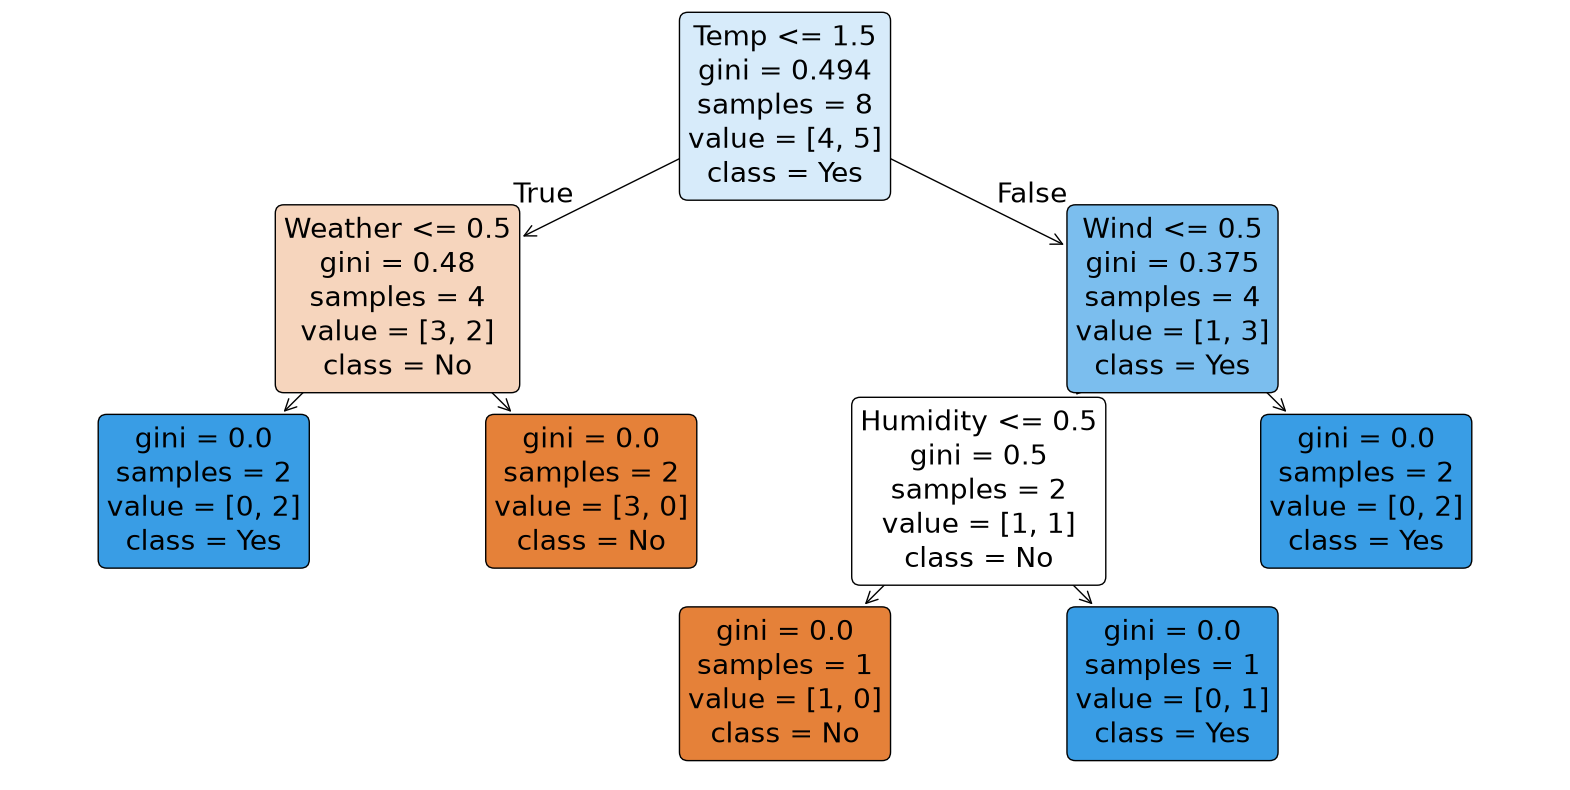

In [10]:
# visualizing one decision tree from the random forest

plt.figure (figsize=(20,10))

plot_tree(
    rf.estimators_[3],
    feature_names = X.columns,
    class_names = ['No' , 'Yes'],
    filled = True,
    rounded = True

)

plt.show()